In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import medmnist
from medmnist import INFO, Evaluator

In [16]:
# 1. SELECT DATASET AND CONFIGURE CPU
# We use 'pneumoniamnist' (2D binary classification of chest X-rays)
data_flag  = 'pneumoniamnist'
download = True

device = torch.device("cpu")
print(f"Forcing training configuration on: {device}")

Forcing training configuration on: cpu


In [17]:
# Fetch dataset specifications automatically
info = INFO[data_flag]
task = info['task'] # 'binary-class'
n_channels = info['n_channels'] # 1 channel (Grayscale X-ray)
n_classes = len(info['label']) # 2 classes: Pneumonia vs Normal

# Get the specific dataset class from MedMNIST wrapper
DataClass = getattr(medmnist, info['python_class'])

# 2. DATA TRANSFORMATION & AUTOMATIC DOWNLOAD
# Images are already 28x28, so we only need to normalize them
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

In [18]:
# Download and load Train and Validation sets automatically
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)

# Create standard PyTorch DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False)

print(f"Dataset Loaded! Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Dataset Loaded! Training samples: 4708, Validation samples: 524


In [19]:
# 3. DEFINE LIGHTWEIGHT CNN FOR 28x28 IMAGES
class MedMNISTCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(MedMNISTCNN, self).__init__()
        
        # Block 1: Input 28x28 -> Conv -> Pool -> 14x14
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Block 2: 14x14 -> Conv -> Pool -> 7x7
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Fully Connected Layers (32 channels * 7x7 image size = 1568 inputs)
        self.fc = nn.Sequential(
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1) # Flatten matrix to vector
        x = self.fc(x)
        return x

In [20]:
# Initialize Network, Loss function, and Adam Optimizer
model = MedMNISTCNN(in_channels=n_channels, num_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
# 4. TRAINING & VALIDATION LOOP
epochs = 5

print("Starting training on CPU...")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        # MedMNIST labels are shape (N, 1), squeeze to (N) for CrossEntropyLoss
        targets = targets.squeeze().long().to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = train_loss / len(train_loader.dataset)
     # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.squeeze().long().to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = (correct / total) * 100
    
    print(f"Epoch [{epoch+1}/{epochs}] -> "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Accuracy: {val_accuracy:.2f}%")

print("Training finished successfully!")

# 5. SAVE MODEL
torch.save(model.state_dict(), 'medmnist_cpu_model.pth')
print("Weights securely saved to medmnist_cpu_model.pth")

Starting training on CPU...
Epoch [1/5] -> Train Loss: 0.1730 | Val Loss: 0.0884 | Val Accuracy: 96.37%
Epoch [2/5] -> Train Loss: 0.1163 | Val Loss: 0.0933 | Val Accuracy: 96.56%
Epoch [3/5] -> Train Loss: 0.0856 | Val Loss: 0.1567 | Val Accuracy: 94.08%
Epoch [4/5] -> Train Loss: 0.0820 | Val Loss: 0.0767 | Val Accuracy: 97.14%
Epoch [5/5] -> Train Loss: 0.0711 | Val Loss: 0.0976 | Val Accuracy: 96.76%
Training finished successfully!
Weights securely saved to medmnist_cpu_model.pth


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# =====================================================================
# VISUALIZATION 1: PLOT SAMPLE MEDICAL IMAGES FROM THE DATASET
# =====================================================================
def plot_dataset_samples(dataset, info, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))
    target_names = info['label']
    
    print("Generating dataset sample visualization...")
    for i in range(num_samples):
        # Grab a random image and label index
        idx = np.random.randint(0, len(dataset))
        image_tensor, label = dataset[idx]
        
        # Un-normalize image from [-1, 1] back to for proper display
        image_array = image_tensor.squeeze().numpy() * 0.5 + 0.5
        
        # FIX: Extract the integer scalar from the MedMNIST array using .item()
        label_idx = str(int(label.item()))
        label_name = target_names[label_idx]
        
        axes[i].imshow(image_array, cmap='gray')
        axes[i].set_title(f"Label: {label_name}\nIndex: {idx}", fontsize=10)
        axes[i].axis('off')
        
    plt.suptitle(f"Sample Images from MedMNIST\n({info['description']})", fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()

Generating dataset sample visualization...


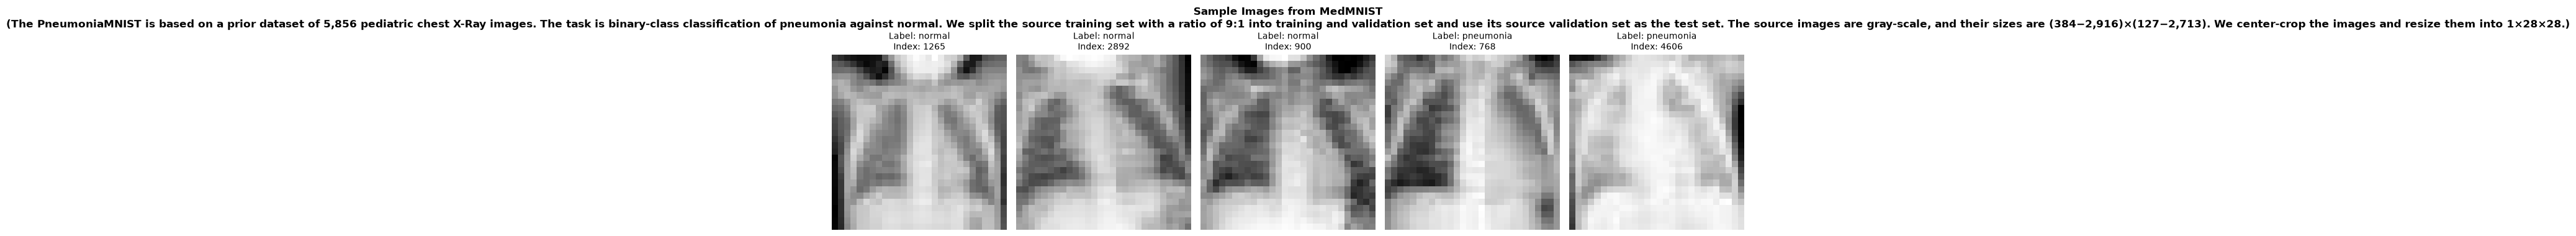


Evaluating model on test dataset...

             CLASSIFICATION REPORT
              precision    recall  f1-score   support

      normal       0.99      0.62      0.76       234
   pneumonia       0.81      1.00      0.90       390

    accuracy                           0.85       624
   macro avg       0.90      0.81      0.83       624
weighted avg       0.88      0.85      0.84       624



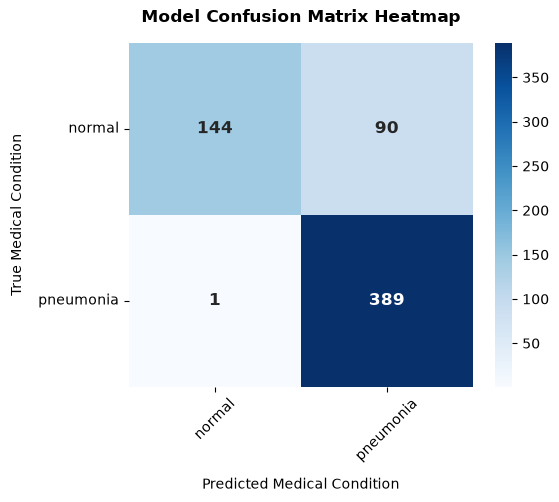

In [14]:
# Call sample plotter using your training dataset
plot_dataset_samples(train_dataset, info, num_samples=5)


# =====================================================================
# EVALUATION & VISUALIZATION 2: CONFUSION MATRIX HEATMAP
# =====================================================================
# 1. Download & Load Test Dataset
test_dataset = DataClass(split='test', transform=data_transform, download=download)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

model.eval()
all_preds = []
all_targets = []

print("\nEvaluating model on test dataset...")
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.squeeze().long().to(device)
        
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# 2. Extract Class Labels Text
target_names = [info['label'][str(i)] for i in range(n_classes)]

# 3. Print Text Classification Report
print("\n" + "="*50)
print("             CLASSIFICATION REPORT")
print("="*50)
print(classification_report(all_targets, all_preds, target_names=target_names))

# 4. Generate and Plot Heatmap
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=target_names, 
    yticklabels=target_names,
    cbar=True,
    square=True,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title("Model Confusion Matrix Heatmap", fontsize=12, weight='bold', pad=15)
plt.xlabel("Predicted Medical Condition", fontsize=10, labelpad=10)
plt.ylabel("True Medical Condition", fontsize=10, labelpad=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()